In [2]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [3]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [4]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [5]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [6]:

!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 832.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

In [1]:
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, NumberOfPoints, BettiCurve
from gtda.diagrams import Scaler as DiagramScaler
from gtda.curves import StandardFeatures

In [2]:

# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())

# Per-channel embedding params — each channel finds its own optimal
# time_delay/dimension via "search", but search runs SEPARATELY on
# the train signal and the test signal (each only sees its own data)
TIME_DELAY = 2   # starting guess for search
DIMENSION  = 3   # starting guess for search

SW_SIZE       = 20
SW_STRIDE     = 10
HOMOLOGY_DIMS = (0, 1)
BETTI_BINS    = 10

TEST_SIZE  = 0.2
RANDOM_STATE = 42

In [3]:
#CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    all_X, all_y = [], []

    csv_dir = os.path.join(
        DATA_DIR,
        f"(S{subject_id:02d})",
        "Preprocessed EEG Data",
        ".csv format"
    )

    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)

        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue

        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()

        data = df[cols].values.astype(np.float64) #here data is storing values like just of our dataset total n timestamps in rows and 14 colums, that way only in  numpy ,represmtation different yet all same

        all_X.append(data)                                    # keep as separate block
        all_y.append(np.full(len(data), label, dtype=int))

    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")

    # Return list of (X_block, y_block) per emotion — NOT concatenated.
    # Concatenating here and splitting 80/20 afterwards would put the
    # entire test set inside the last emotion block (G4/Funny) only.
    return all_X, all_y




In [4]:

# ── CELL 6: Birth/Death/Lifetime stats ───────────────────────────
def persistence_stats(X_pd):
    n_windows = X_pd.shape[0]
    all_rows  = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.extend([0.0] * 6)
            else:
                b = finite[:, 0]
                d = finite[:, 1]
                l = d - b
                row.extend([b.mean(), b.std(), d.mean(), d.std(), l.mean(), l.std()])
        all_rows.append(row)
    return np.array(all_rows)
#total n windows. each window- 12 features, (6*2) ,*2? as we have two homology_dims.

it is using persisetent homology computed later on. to find out the stats/

In [5]:

# ── CELL 7: TDA features for one channel split ───────────────────
def tda_on_signal(signal, labels):
    """
    Run TDA pipeline on a 1-D signal. Each call independently searches
    for the optimal time_delay/dimension for THIS signal only — so when
    called separately on train and test, there's no leakage between them.

    signal : (T,)
    labels : (T,)

    Returns
    -------
    X_feat : (n_windows, 28)
    y_win  : (n_windows,)
    """
    # Step 1 — SingleTakensEmbedding, per-channel optimal params via search.
    # "search" looks ONLY at the signal passed in here — when called on the
    # train split it never sees test data, and vice versa.
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,#use all cpus.
    )
    X_emb, y_emb = STE.fit_transform_resample(signal, labels)

    # Step 2 — SlidingWindow over embedded point cloud
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)#x_win.shape has(no of windows,window_size,embedding_dimension)

    # Step 3 — VietorisRipsPersistence
    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = VR.fit_transform(X_win)
    X_pd = DiagramScaler().fit_transform(X_pd)#
#The persistence diagrams are scaled/normalized.

#This makes the numerical ranges more comparable across different windows before feature extraction. It helps ensure that later features are not dominated simply because one diagram has larger birth/death values than another.

#Notice that the topology (which features exist) does not change—the coordinates are just rescaled.
#



    # Step 4 — All persistence features
    feat_bdl = persistence_stats(X_pd)  #cell-6 used.                                        # (n_win, 12)
    feat_pe  = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd)  # (n_win, 2)
    feat_amp = Amplitude(metric="landscape", order=None).fit_transform(X_pd)   # (n_win, 2)
    feat_np  = NumberOfPoints().fit_transform(X_pd)                            # (n_win, 2)
    betti    = BettiCurve(n_bins=BETTI_BINS).fit_transform(X_pd)
    feat_bc  = StandardFeatures().fit_transform(betti)                         # (n_win, 10)

    X_feat = np.hstack([feat_bdl, feat_pe, feat_amp, feat_np, feat_bc])       # (n_win, 28)
    return X_feat, y_win

In [6]:
# ── CELL 8: Extract features from one subject ─────────────────────
def extract_subject_features(subject_id):
    """
    Load subject data as separate emotion blocks. For EACH emotion block,
    split 80/20 on its own raw timepoints (so train and test both contain
    all 4 emotions), then run TDA on train and test signals separately.
    Returns pooled train and test feature matrices for this subject.
    """
    blocks_X, blocks_y = load_subject(subject_id)

    # Split each emotion block 80/20 individually, then stitch the splits
    # back together per channel — this keeps the time series CONTIGUOUS
    # within each emotion (needed for Takens embedding) while ensuring
    # both train and test contain samples from all 4 emotions.
    tr_blocks_X, tr_blocks_y = [], []
    te_blocks_X, te_blocks_y = [], []

    for X_block, y_block in zip(blocks_X, blocks_y):
        n = len(y_block)
        split_idx = int(n * 0.8)
        tr_blocks_X.append(X_block[:split_idx])
        tr_blocks_y.append(y_block[:split_idx])
        te_blocks_X.append(X_block[split_idx:])
        te_blocks_y.append(y_block[split_idx:])

    X_tr_all, y_tr_all = [], None
    X_te_all, y_te_all = [], None
    min_tr, min_te     = None, None

    n_channels = blocks_X[0].shape[1]

    for ch_idx in range(n_channels):
        ch = CHANNELS[ch_idx]
        print(f"  S{subject_id:02d} [{ch_idx+1:02d}/14] {ch} ...", end=" ", flush=True)
        try:
            feat_tr_parts, y_tr_parts = [], []
            feat_te_parts, y_te_parts = [], []

            # Run TDA separately on EACH emotion's train slice and test slice,
            # then stack results across emotions for this channel.
            for X_tr_b, y_tr_b, X_te_b, y_te_b in zip(
                tr_blocks_X, tr_blocks_y, te_blocks_X, te_blocks_y
            ):
                f_tr, yw_tr = tda_on_signal(X_tr_b[:, ch_idx], y_tr_b)#has shape(n_win,28),cell7 -called.
                f_te, yw_te = tda_on_signal(X_te_b[:, ch_idx], y_te_b)
                feat_tr_parts.append(f_tr)
                y_tr_parts.append(yw_tr)
                feat_te_parts.append(f_te)
                y_te_parts.append(yw_te)

            # now it has all features of that one channel across all blocks os subject.

            feat_tr = np.vstack(feat_tr_parts)
            #and now they are combined in vertical stack.(for one channel).
            y_tr_win = np.concatenate(y_tr_parts)
            feat_te = np.vstack(feat_te_parts)
            y_te_win = np.concatenate(y_te_parts)

            X_tr_all.append(feat_tr)
            X_te_all.append(feat_te)

            if y_tr_all is None:
                y_tr_all = y_tr_win
                y_te_all = y_te_win
                min_tr   = feat_tr.shape[0]
                min_te   = feat_te.shape[0]
            else:
                min_tr = min(min_tr, feat_tr.shape[0])
                min_te = min(min_te, feat_te.shape[0])

            print(f"tr_wins={feat_tr.shape[0]}, te_wins={feat_te.shape[0]}")
        except Exception as e:
            print(f"SKIPPED — {e}")

    if not X_tr_all:
        return None, None, None, None

    X_tr = np.hstack([f[:min_tr] for f in X_tr_all])
    X_te = np.hstack([f[:min_te] for f in X_te_all])
    y_tr = y_tr_all[:min_tr]
    y_te = y_te_all[:min_te]

    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

    return X_tr, y_tr, X_te, y_te

    #now: we jave training feture matrix, training labels, testing feature matrix,testing lables.



first in cell 8 there was vstack of same channel diff block, then different channerls were hstacked.

In [7]:

# ── CELL 9: Confusion matrix plot ─────────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


until now we learned how to process: one subject and extracted its features-training and testing...now we will be doing for all subjects

In [15]:

# ── CELL 10: Collect features from all subjects ───────────────────
print("Extracting TDA features from all subjects...")

all_X_tr, all_y_tr = [], []
all_X_te, all_y_te = [], []

for sid in range(1, 29):
    print(f"\n{'='*50}")
    print(f"Subject S{sid:02d}")
    print(f"{'='*50}")
    try:
        X_tr, y_tr, X_te, y_te = extract_subject_features(sid)
        if X_tr is not None:
            all_X_tr.append(X_tr)
            all_y_tr.append(y_tr)
            all_X_te.append(X_te)
            all_y_te.append(y_te)
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")

# Pool all subjects together
X_train = np.vstack(all_X_tr)
y_train = np.concatenate(all_y_tr)
X_test  = np.vstack(all_X_te)
y_test  = np.concatenate(all_y_te)

print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")


Extracting TDA features from all subjects...

Subject S01
  S01 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S01 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S01 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S01 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S01 [05/14] T7 ... tr_wins=12232, te_wins=3052
  S01 [06/14] P7 ... tr_wins=12232, te_wins=3052
  S01 [07/14] O1 ... tr_wins=12232, te_wins=3052
  S01 [08/14] O2 ... tr_wins=12232, te_wins=3052
  S01 [09/14] P8 ... tr_wins=12232, te_wins=3052
  S01 [10/14] T8 ... tr_wins=12232, te_wins=3052
  S01 [11/14] FC6 ... tr_wins=12232, te_wins=3052
  S01 [12/14] F4 ... tr_wins=12232, te_wins=3052
  S01 [13/14] F8 ... tr_wins=12232, te_wins=3052
  S01 [14/14] AF4 ... tr_wins=12232, te_wins=3052

Subject S02
  S02 [01/14] AF3 ... tr_wins=12232, te_wins=3052
  S02 [02/14] F7 ... tr_wins=12232, te_wins=3052
  S02 [03/14] F3 ... tr_wins=12232, te_wins=3052
  S02 [04/14] FC5 ... tr_wins=12232, te_wins=3052
  S02 [05/14] T7 ... tr_wins=12232, te_wi

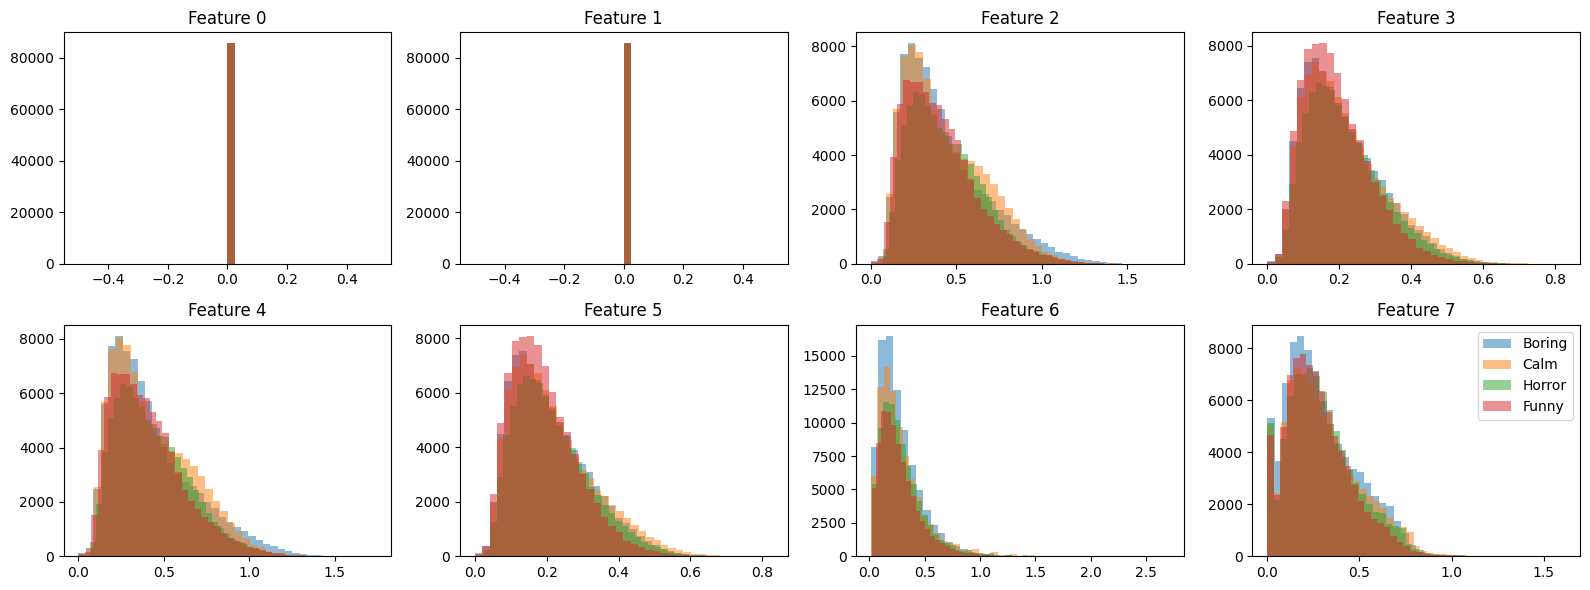

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    for cls in range(4):
        vals = X_train[y_train == cls, i]
        ax.hist(vals, bins=40, alpha=0.5, label=EMOTION_LABELS[cls])
    ax.set_title(f"Feature {i}")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
 #── CELL 11: Scale + Train MLP ────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Drop zero-variance features before feeding into MLP
from sklearn.feature_selection import VarianceThreshold
selector   = VarianceThreshold(threshold=0.01)
X_train_sc = selector.fit_transform(X_train_sc)
X_test_sc  = selector.transform(X_test_sc)
print(f"Features after variance filter: {X_train_sc.shape[1]}")

# Convert to tensors
X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train,    dtype=torch.long)
X_te_t = torch.tensor(X_test_sc,  dtype=torch.float32)
y_te_t = torch.tensor(y_test,     dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=512, shuffle=True)


Features after variance filter: 248


In [18]:

# ── MLP definition ────────────────────────────────────────────────
class TDA_MLP(nn.Module):
    def __init__(self, in_dim, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [21]:

model     = TDA_MLP(in_dim=X_train_sc.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training loop with early stopping ────────────────────────────
EPOCHS        = 100
PATIENCE      = 10   # stop if val_acc doesn't improve for 10 epochs
best_val_acc  = 0.0
best_weights  = None
patience_ctr  = 0

print(f"\nTraining MLP (early stopping patience={PATIENCE})...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    # validation every epoch
    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()
    val_acc   = accuracy_score(y_test, val_pred)
    train_acc = correct / total
    scheduler.step(1 - val_acc)   # ReduceLROnPlateau monitors val loss proxy

    if epoch % 5 == 0:
        print(f"  Epoch {epoch:03d} — loss={total_loss/total:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    # save best weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch} — best val_acc={best_val_acc:.4f}")
            break

    model.train()



Training MLP (early stopping patience=10)...
  Epoch 005 — loss=0.9444, train_acc=0.6143, val_acc=0.3116
  Epoch 010 — loss=0.8169, train_acc=0.6805, val_acc=0.3240
  Epoch 015 — loss=0.7672, train_acc=0.7055, val_acc=0.3171
  Epoch 020 — loss=0.7209, train_acc=0.7268, val_acc=0.3255

  Early stopping at epoch 21 — best val_acc=0.3273



Loaded best model (val_acc=0.3238)

Test Accuracy : 0.3238

              precision    recall  f1-score   support

      Boring       0.33      0.36      0.35     21364
        Calm       0.32      0.27      0.29     21364
      Horror       0.31      0.46      0.37     21364
       Funny       0.34      0.20      0.26     21364

    accuracy                           0.32     85456
   macro avg       0.33      0.32      0.32     85456
weighted avg       0.33      0.32      0.32     85456



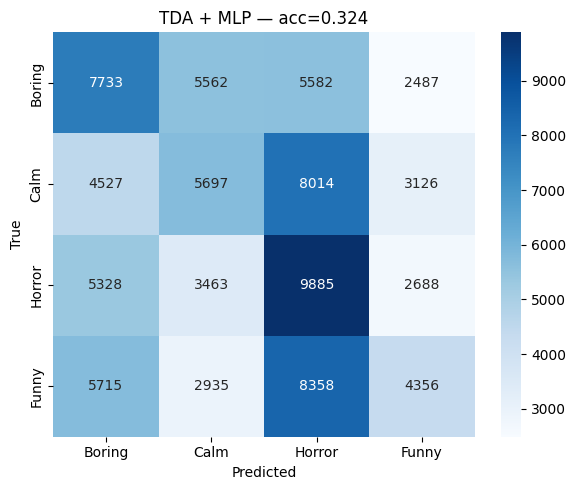

Saved → tda_mlp_results.csv


In [20]:
# Load best weights before final evaluation
model.load_state_dict(best_weights)
print(f"\nLoaded best model (val_acc={best_val_acc:.4f})")
model.eval()
with torch.no_grad():
    y_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy : {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=EMOTION_LABELS))

plot_cm(y_test, y_pred, f"TDA + MLP — acc={acc:.3f}")

pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(
    "tda_mlp_results.csv", index=False
)
print("Saved → tda_mlp_results.csv")
